# Gomoku 6x6 + ANN thay Heuristic cho Minimax

Đồ án Phần 2 & Phần 3 — Nhập môn Trí tuệ Nhân tạo.
Trò chơi: **Gomoku thu nhỏ** (lưới 6x6, thắng khi có 4 quân liên tiếp ngang/dọc/chéo).

Notebook này gộp toàn bộ mã nguồn của đồ án thành các cell, chạy tuần tự từ trên xuống dưới trên Google Colab:

1. Cài thư viện
2. `gomoku_env` — môi trường bàn cờ
3. `heuristic` — hàm lượng giá viết tay
4. `minimax_ai` — Minimax (không Alpha-Beta, để đơn giản)
5. `data_generation` — sinh dữ liệu self-play
6. **Phần 2: Thí nghiệm Kiểm chứng** — Underfitting / Overfitting / Chuẩn hóa, ROC/AUC, Cross-validation
7. `train_ann` — huấn luyện ANN
8. `ann_minimax_integration` — thay heuristic tay bằng ANN trong Minimax (gọi thẳng `model.predict()`)
9. `evaluate_models` — đánh giá ANN-Minimax vs Random

> Lưu ý: chạy đúng thứ tự cell vì các bước sau phụ thuộc biến/hàm của cell trước (không còn `import` chéo giữa các file .py nữa vì tất cả đã ở chung 1 notebook).


In [24]:
# pip install -q tensorflow numpy matplotlib


In [25]:
import numpy as np
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold
from tensorflow import keras
from tensorflow.keras import layers

## 1. Bàn cờ Gomoku 6x6

Bàn cờ: luật chơi, kiểm tra thắng, sinh nước đi hợp lệ. Đây là phần PHẢI tự hiểu rõ vì cả đồ án phụ thuộc cách biểu diễn trạng thái này.

In [26]:
"""
Bàn cờ Gomoku thu nhỏ: lưới 6x6, thắng khi có 4 quân liên tiếp
(ngang / dọc / chéo).

Quy ước giá trị ô:
     1  -> quân X (người/AI đi trước)
    -1  -> quân O (người/AI đi sau)
     0  -> ô trống
"""

BOARD_SIZE = 6
WIN_LEN = 4


class GomokuBoard:
    def __init__(self, size: int = BOARD_SIZE, win_len: int = WIN_LEN):
        self.size = size
        self.win_len = win_len
        self.grid = np.zeros((size, size), dtype=np.int8)
        self.current_player = 1   # X đi trước
        self.winner = None        # None = chưa kết thúc, 0 = hòa, 1/-1 = ai thắng
        self.move_history = []

    # ---------- Tiện ích cơ bản ----------
    def clone(self):
        new_board = GomokuBoard(self.size, self.win_len)
        new_board.grid = self.grid.copy()
        new_board.current_player = self.current_player
        new_board.winner = self.winner
        new_board.move_history = self.move_history.copy()
        return new_board

    def is_full(self) -> bool:
        return not np.any(self.grid == 0)

    def to_vector(self) -> np.ndarray:
        """Chuyển bàn cờ thành vector 1D (36,) làm input cho ANN."""
        return self.grid.flatten().astype(np.float32)

    # ---------- Sinh nước đi ----------
    def legal_moves(self):
        """Trả về list (row, col) các ô còn trống."""
        rows, cols = np.where(self.grid == 0)
        return list(zip([int(r) for r in rows], [int(c) for c in cols]))

    def candidate_moves(self, radius: int = 1):
        """
        Giới hạn không gian tìm kiếm: chỉ xét các ô trống nằm trong bán kính
        `radius` quanh các quân đã đặt. Nếu bàn cờ trống -> chỉ xét ô trung tâm.
        Đây là kỹ thuật cắt giảm nhánh thực tế (move ordering / pruning thô),
        bắt buộc phải có để Minimax chạy đủ nhanh trên lưới 6x6.
        """
        if np.all(self.grid == 0):
            c = self.size // 2
            return [(c, c)]

        occupied = np.argwhere(self.grid != 0)
        candidates = set()
        for (r, c) in occupied:
            for dr in range(-radius, radius + 1):
                for dc in range(-radius, radius + 1):
                    nr, nc = int(r) + dr, int(c) + dc
                    if 0 <= nr < self.size and 0 <= nc < self.size:
                        if self.grid[nr, nc] == 0:
                            candidates.add((nr, nc))
        if not candidates:  # bàn đầy nhưng chưa ai thắng (hòa)
            return []
        return list(candidates)

    # ---------- Thực hiện nước đi ----------
    def make_move(self, row: int, col: int):
        if self.grid[row, col] != 0:
            raise ValueError(f"Ô ({row},{col}) đã có quân.")
        self.grid[row, col] = self.current_player
        self.move_history.append((row, col, self.current_player))
        self._check_winner_at(row, col)
        self.current_player *= -1  # đổi lượt

    def undo_move(self):
        if not self.move_history:
            return
        r, c, _ = self.move_history.pop()
        self.grid[r, c] = 0
        self.winner = None
        self.current_player *= -1

    # ---------- Kiểm tra thắng ----------
    def _check_winner_at(self, row: int, col: int):
        """Chỉ cần kiểm tra 4 hướng đi qua ô vừa đánh (nhanh hơn quét toàn bàn)."""
        player = self.grid[row, col]
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
        for dr, dc in directions:
            count = 1
            # đi theo chiều dương
            r, c = row + dr, col + dc
            while 0 <= r < self.size and 0 <= c < self.size and self.grid[r, c] == player:
                count += 1
                r += dr
                c += dc
            # đi theo chiều âm
            r, c = row - dr, col - dc
            while 0 <= r < self.size and 0 <= c < self.size and self.grid[r, c] == player:
                count += 1
                r -= dr
                c -= dc
            if count >= self.win_len:
                self.winner = int(player)
                return
        if self.is_full():
            self.winner = 0  # hòa

    def is_terminal(self) -> bool:
        return self.winner is not None

    # ---------- Hiển thị ----------
    def render(self):
        symbols = {1: "X", -1: "O", 0: "."}
        for row in self.grid:
            print(" ".join(symbols[v] for v in row))
        print()


if __name__ == "__main__":
    # Test nhanh: tạo bàn cờ và đánh thử 1 đường thắng ngang
    b = GomokuBoard()
    b.render()
    moves = [(2, 2), (3, 2), (2, 3), (3, 3), (2, 4), (3, 4), (2, 5)]
    for (r, c) in moves:
        b.make_move(r, c)
    b.render()
    print("Người thắng:", b.winner)  # kỳ vọng: 1 (X thắng vì 2,2-2,3-2,4-2,5)
    print("Candidate moves count:", len(b.candidate_moves()))


. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .

. . . . . .
. . . . . .
. . X X X X
. . O O O .
. . . . . .
. . . . . .

Người thắng: 1
Candidate moves count: 13


## 2. Hàm Heuristic

Hàm heuristic THỦ CÔNG, đây chính là phần được thay bằng ANN ở phần sau.

In [27]:
"""
Hàm heuristic cho Gomoku. Phải hiểu rõ hàm này để:
  1. Biết ANN "đang học" để bắt chước cái gì.
  2. Trả lời phản biện vì sao chọn cách tính điểm này.

Ý tưởng: quét tất cả các "cửa sổ" độ dài WIN_LEN (4 ô) theo 4 hướng
(ngang, dọc, 2 chéo). Với mỗi cửa sổ chỉ có quân của 1 bên (bên kia chưa
chặn), tính điểm theo số quân đã có trong cửa sổ đó — cửa sổ có 3 quân
sống thì nguy hiểm hơn cửa sổ có 1 quân.

Điểm trả về luôn được tính theo góc nhìn của X (số dương = lợi cho X,
số âm = lợi cho O), giống quy ước minimax maximizing=X, minimizing=O.
"""
# Trọng số cho từng số quân trong 1 cửa sổ 4 ô còn khả năng thắng.
# Tăng phi tuyến để nhấn mạnh thế cờ gần thắng nguy hiểm hơn nhiều.
WINDOW_SCORE = {0: 0, 1: 1, 2: 8, 3: 40, 4: 100000}


def _all_windows(size: int, win_len: int):
    """Sinh danh sách các cửa sổ (list toạ độ) theo 4 hướng trên lưới size x size."""
    windows = []
    directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
    for dr, dc in directions:
        for r in range(size):
            for c in range(size):
                cells = []
                for k in range(win_len):
                    rr, cc = r + dr * k, c + dc * k
                    if 0 <= rr < size and 0 <= cc < size:
                        cells.append((rr, cc))
                    else:
                        break
                if len(cells) == win_len:
                    windows.append(cells)
    return windows


# Tính sẵn 1 lần (không đổi giữa các bàn cờ vì size/win_len cố định) để tăng tốc.
_WINDOWS_CACHE = _all_windows(BOARD_SIZE, WIN_LEN)


def evaluate_heuristic(board: GomokuBoard) -> float:
    """
    Trả về điểm heuristic của bàn cờ theo góc nhìn X.
    Nếu đã có người thắng/hòa thì trả điểm "tuyệt đối" luôn.
    """
    if board.winner == 1:
        return 100000.0
    if board.winner == -1:
        return -100000.0
    if board.winner == 0:
        return 0.0

    grid = board.grid
    score = 0.0
    for window in _WINDOWS_CACHE:
        values = [grid[r, c] for (r, c) in window]
        x_count = values.count(1)
        o_count = values.count(-1)
        if x_count > 0 and o_count > 0:
            continue  # cửa sổ đã bị chặn 2 bên -> không ai thắng được ở đây nữa
        if x_count > 0:
            score += WINDOW_SCORE[x_count]
        elif o_count > 0:
            score -= WINDOW_SCORE[o_count]
    return float(score)


if __name__ == "__main__":
    b = GomokuBoard()
    print("Bàn trống, điểm:", evaluate_heuristic(b))  # kỳ vọng 0

    # X có 3 quân sống liên tiếp (mối nguy lớn) -> điểm phải dương rõ rệt
    for (r, c) in [(2, 2), (2, 3), (2, 4)]:
        b.grid[r, c] = 1
    print("X có 3 quân sống liên tiếp, điểm:", evaluate_heuristic(b))

    # Thêm O chặn 1 đầu -> điểm phải giảm so với trên
    b2 = b.clone()
    b2.grid[2, 5] = -1
    print("X có 3 quân nhưng bị O chặn 1 đầu, điểm:", evaluate_heuristic(b2))


Bàn trống, điểm: 0.0
X có 3 quân sống liên tiếp, điểm: 110.0
X có 3 quân nhưng bị O chặn 1 đầu, điểm: 66.0


## 3. Minimax cơ bản

`eval_fn` truyền vào `minimax()` chính là "khe cắm" để thay heuristic tay bằng ANN.

Bản này KHÔNG cắt tỉa Alpha-Beta để source đơn giản, dễ đọc hơn — đổi lại cây tìm kiếm
sẽ duyệt nhiều nút hơn, nên khi dùng ANN làm eval_fn ở Phần 6-7 cần chọn `depth` nhỏ
(1-2) để chương trình chạy trong thời gian hợp lý.


In [28]:
"""
Minimax THUẦN cho Gomoku.

Điểm quan trọng nhất của file này: hàm `minimax()` nhận vào một
`eval_fn` (hàm lượng giá) làm tham số -> đây chính là "khe cắm" để
Phần 3 của đồ án thay heuristic tay bằng ANN, đúng như boilerplate
trong đề bài:

    def get_heuristic_value(board_state):
        input_vector = preprocess(board_state)
        score = model.predict(input_vector)
        return score

Ở đây `eval_fn` đóng vai trò của `get_heuristic_value`.

Không dùng Alpha-Beta để source đơn giản hơn: minimax sẽ duyệt HẾT các
nhánh trong `depth` cho phép, không cắt bớt nhánh nào. Vì vậy nên dùng
`depth` nhỏ (2-3) khi eval_fn là heuristic tay (nhanh), và nhỏ hơn nữa
(1-2) khi eval_fn là ANN (chậm hơn vì phải gọi model.predict()).
"""


def minimax(board: GomokuBoard, depth: int, maximizing: bool, eval_fn):
    """
    board       : GomokuBoard hiện tại
    depth       : độ sâu còn lại được phép tìm
    maximizing  : True nếu lượt này là X (maximizing), False nếu là O
    eval_fn     : hàm (board) -> float, dùng khi hết depth hoặc bàn kết thúc
    """
    if board.is_terminal() or depth == 0:
        return eval_fn(board), None

    moves = board.candidate_moves(radius=1)
    if not moves:
        return eval_fn(board), None

    best_move = None

    if maximizing:
        best_value = -math.inf
        for (r, c) in moves:
            board.make_move(r, c)
            value, _ = minimax(board, depth - 1, False, eval_fn)
            board.undo_move()
            if value > best_value:
                best_value = value
                best_move = (r, c)
        return best_value, best_move
    else:
        best_value = math.inf
        for (r, c) in moves:
            board.make_move(r, c)
            value, _ = minimax(board, depth - 1, True, eval_fn)
            board.undo_move()
            if value < best_value:
                best_value = value
                best_move = (r, c)
        return best_value, best_move


def get_best_move(board: GomokuBoard, depth: int, eval_fn):
    """Trả về nước đi tốt nhất cho người chơi hiện tại (board.current_player)."""
    maximizing = (board.current_player == 1)
    _, move = minimax(board, depth, maximizing, eval_fn)
    if move is None:
        # fallback an toàn: không tìm được nước (hiếm khi xảy ra) -> chọn ô trống đầu tiên
        legal = board.legal_moves()
        move = legal[0] if legal else None
    return move


if __name__ == "__main__":
    import time

    b = GomokuBoard()
    # Test 1: X đã có 3 quân sống ngang, O chưa chặn -> Minimax phải chọn đi tiếp
    # để thắng (hoặc chặn nếu là O), không đi lung tung.
    b.make_move(2, 2)  # X
    b.make_move(0, 0)  # O (nước đi ngẫu nhiên, không liên quan)
    b.make_move(2, 3)  # X
    b.make_move(0, 1)  # O
    b.make_move(2, 4)  # X -> X đang có 3 quân sống (2,2)-(2,3)-(2,4)
    b.render()
    print("Đến lượt:", "X" if b.current_player == 1 else "O")

    t0 = time.time()
    move = get_best_move(b, depth=3, eval_fn=evaluate_heuristic)
    t1 = time.time()
    print("O nên chặn ở:", move, f"(thời gian: {t1 - t0:.3f}s)")
    # Kỳ vọng: O phải chặn ở (2,1) hoặc (2,5) để không thua ngay


O O . . . .
. . . . . .
. . X X X .
. . . . . .
. . . . . .
. . . . . .

Đến lượt: O
O nên chặn ở: (1, 2) (thời gian: 0.211s)


## 4. `data_generation` — Sinh dữ liệu self-play

Cho Minimax-tay tự đấu với chính nó để sinh dataset (board, heuristic score) cho việc huấn luyện ANN.

**Chạy cell dưới sẽ mất khoảng 20-60 giây** (400 trận self-play) và lưu ra `gomoku_dataset.npz`.

In [29]:
"""
Sinh dữ liệu huấn luyện cho ANN bằng cách cho Minimax (dùng heuristic)
tự đấu với chính nó nhiều trận. Tại MỖI trạng thái bàn cờ đi qua trong trận,
ta tính sẵn điểm heuristic THẬT (bằng hàm tay) và lưu lại làm "nhãn" (label).

  -> Input  (X) : vector 36 chiều của bàn cờ
  -> Output (y) : điểm heuristic tương ứng (do hàm tay tính ra)

Mục tiêu: ANN sẽ học để BẮT CHƯỚC hàm heuristic tay, để sau đó ta có thể
dùng ANN thay cho hàm tay trong Minimax (đúng yêu cầu Phần 3 đề bài).

Có thêm yếu tố ngẫu nhiên (epsilon) khi chọn nước đi để bàn cờ đi qua
nhiều trạng thái đa dạng hơn, tránh data chỉ tập trung vào 1-2 lối chơi.
"""


def play_one_self_play_game(depth: int = 2, epsilon: float = 0.3, max_moves: int = 36):
    """
    Chơi 1 trận Minimax-vs-Minimax (cùng dùng heuristic), có epsilon%
    khả năng đi ngẫu nhiên thay vì đi nước tốt nhất -> tăng đa dạng trạng thái.

    Trả về list các tuple (board_vector, heuristic_score).
    """
    board = GomokuBoard()
    samples = []

    while not board.is_terminal() and len(board.move_history) < max_moves:
        # Lưu lại trạng thái TRƯỚC khi đi (kèm nhãn = heuristic của chính trạng thái này)
        samples.append((board.to_vector(), evaluate_heuristic(board)))

        moves = board.candidate_moves(radius=1)
        if not moves:
            break

        if random.random() < epsilon:
            move = random.choice(moves)
        else:
            move = get_best_move(board, depth=depth, eval_fn=evaluate_heuristic)
            if move is None:
                move = random.choice(moves)

        board.make_move(*move)

    # Lưu luôn trạng thái cuối (thắng/thua/hòa) để ANN cũng học được các thế kết thúc
    samples.append((board.to_vector(), evaluate_heuristic(board)))
    return samples


def generate_dataset(n_games: int = 400, depth: int = 2, epsilon: float = 0.3, seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    all_X, all_y = [], []
    for i in range(n_games):
        samples = play_one_self_play_game(depth=depth, epsilon=epsilon)
        for vec, score in samples:
            all_X.append(vec)
            all_y.append(score)
        if (i + 1) % 50 == 0:
            print(f"  Đã chơi {i + 1}/{n_games} trận, tổng {len(all_X)} mẫu...")

    X = np.array(all_X, dtype=np.float32)
    y = np.array(all_y, dtype=np.float32)
    return X, y


if __name__ == "__main__":
    import time

    t0 = time.time()
    X, y = generate_dataset(n_games=400, depth=2, epsilon=0.3)
    t1 = time.time()

    print(f"\nTổng số mẫu: {X.shape[0]}, thời gian sinh data: {t1 - t0:.1f}s")
    print("X shape:", X.shape, "| y shape:", y.shape)
    print("y min/max/mean:", y.min(), y.max(), y.mean())

    np.savez_compressed("gomoku_dataset.npz", X=X, y=y)
    print("Đã lưu dataset vào gomoku_dataset.npz")


  Đã chơi 50/400 trận, tổng 665 mẫu...
  Đã chơi 100/400 trận, tổng 1349 mẫu...
  Đã chơi 150/400 trận, tổng 1968 mẫu...
  Đã chơi 200/400 trận, tổng 2590 mẫu...
  Đã chơi 250/400 trận, tổng 3165 mẫu...
  Đã chơi 300/400 trận, tổng 3865 mẫu...
  Đã chơi 350/400 trận, tổng 4445 mẫu...
  Đã chơi 400/400 trận, tổng 5025 mẫu...

Tổng số mẫu: 5025, thời gian sinh data: 45.6s
X shape: (5025, 36) | y shape: (5025,)
y min/max/mean: -100000.0 100000.0 3540.5334
Đã lưu dataset vào gomoku_dataset.npz


## 5. Phần 2: Thí nghiệm Kiểm chứng — Underfitting / Overfitting / Chuẩn hóa

Phần này sử dụng **chính dữ liệu Gomoku** (đã sinh từ self-play ở notebook chính)
để minh chứng 3 trạng thái của mô hình ANN thông qua đồ thị trực quan.

**Chuyển đổi bài toán:** Dữ liệu gốc là regression (dự đoán điểm heuristic).
Ở đây ta chuyển sang **phân loại 3 lớp** để sử dụng được các chỉ số
**Accuracy**, **ROC/AUC** và **Cross-validation** đúng yêu cầu đề bài:

| Class | Ý nghĩa | Điều kiện |
|---|---|---|
| 0 | O đang thắng thế | heuristic < −50 |
| 1 | Cân bằng | −50 ≤ heuristic ≤ 50 |
| 2 | X đang thắng thế | heuristic > 50 |

> **Lưu ý:** Sử dụng dữ liệu `gomoku_dataset.npz` đã sinh ở bước 4 phía trên.

### 5.0 Chuẩn bị dữ liệu phân loại

Load dataset Gomoku, chuyển nhãn heuristic sang 3 lớp, chia Train/Val/Test
theo tỉ lệ **70/15/15**.

Tong mau: 5025, Features: 36
Heuristic score — min: -100000, max: 100000, mean: 3540.5

Phan bo lop (nguong +-50):
  Class 0 (O thang the): 259 mau (5.2%)
  Class 1 (Can bang): 3599 mau (71.6%)
  Class 2 (X thang the): 1167 mau (23.2%)

Sau khi chia:
  Train : 3517 (70%)
  Val   : 754 (15%)
  Test  : 754 (15%)


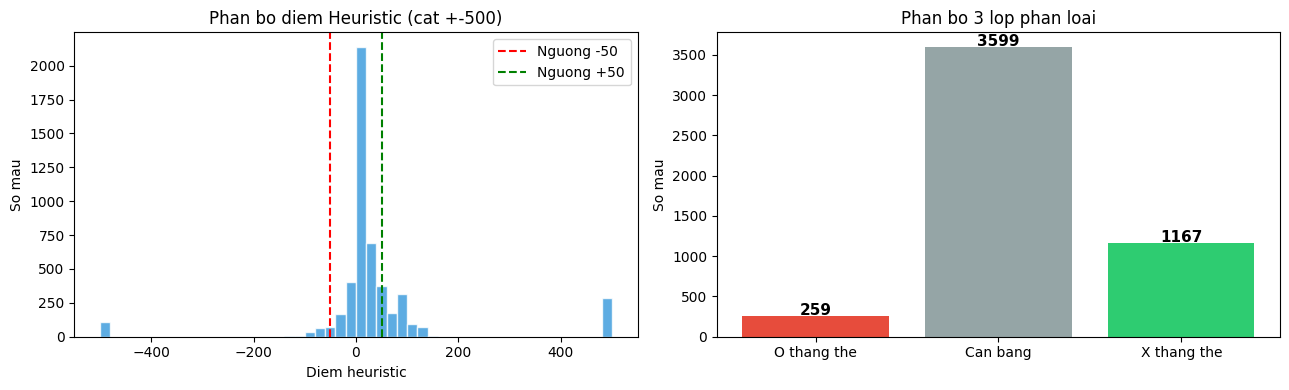

In [30]:
# ========== Load dataset ==========
data = np.load('gomoku_dataset.npz')
X_all, y_raw = data['X'], data['y']
print(f'Tong mau: {len(X_all)}, Features: {X_all.shape[1]}')
print(f'Heuristic score — min: {y_raw.min():.0f}, max: {y_raw.max():.0f}, mean: {y_raw.mean():.1f}')

# ========== Chuyen sang 3 lop phan loai ==========
THRESHOLD = 50
y_class = np.where(y_raw < -THRESHOLD, 0,
                   np.where(y_raw > THRESHOLD, 2, 1))

CLASS_NAMES = {0: 'O thang the', 1: 'Can bang', 2: 'X thang the'}
print(f'\nPhan bo lop (nguong +-{THRESHOLD}):')
for cls in range(3):
    cnt = np.sum(y_class == cls)
    print(f'  Class {cls} ({CLASS_NAMES[cls]}): {cnt} mau ({cnt/len(y_class):.1%})')

# ========== Chia Train / Val / Test = 70% / 15% / 15% ==========
X_temp, X_test_cls, y_temp, y_test_cls = train_test_split(
    X_all, y_class, test_size=0.15, random_state=42, stratify=y_class)
X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f'\nSau khi chia:')
print(f'  Train : {len(X_train_cls)} ({len(X_train_cls)/len(X_all):.0%})')
print(f'  Val   : {len(X_val_cls)} ({len(X_val_cls)/len(X_all):.0%})')
print(f'  Test  : {len(X_test_cls)} ({len(X_test_cls)/len(X_all):.0%})')

# One-hot encode cho categorical_crossentropy
y_train_oh = to_categorical(y_train_cls, 3)
y_val_oh   = to_categorical(y_val_cls, 3)
y_test_oh  = to_categorical(y_test_cls, 3)

# ========== Do thi phan bo ==========
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram diem heuristic goc (cat +-500 de de nhin)
y_clip = np.clip(y_raw, -500, 500)
axes[0].hist(y_clip, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(-THRESHOLD, color='red', linestyle='--', label=f'Nguong -{THRESHOLD}')
axes[0].axvline(THRESHOLD, color='green', linestyle='--', label=f'Nguong +{THRESHOLD}')
axes[0].set_title('Phan bo diem Heuristic (cat +-500)')
axes[0].set_xlabel('Diem heuristic')
axes[0].set_ylabel('So mau')
axes[0].legend()

# Bar chart 3 lop
counts = [np.sum(y_class == i) for i in range(3)]
colors_bar = ['#e74c3c', '#95a5a6', '#2ecc71']
bars = axes[1].bar([CLASS_NAMES[i] for i in range(3)], counts, color=colors_bar)
axes[1].set_title('Phan bo 3 lop phan loai')
axes[1].set_ylabel('So mau')
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(cnt), ha='center', fontsize=11, fontweight='bold')

fig.tight_layout()
plt.show()

In [31]:
# Ham ho tro ve do thi Loss va Accuracy qua cac Epoch
def plot_experiment(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Categorical Crossentropy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim([0, 1.05])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

### 5.1 Thi nghiem 1: UNDERFITTING

**Muc tieu:** Chung minh mo hinh **khong du kha nang hoc** khi mang qua nong va train qua it.

**Cau hinh co tinh:**
- Chi **1 lop an voi 4 node** (qua it tham so de bieu dien du cac mau)
- Chi train **5 epoch** (qua it de hoi tu)

**Ky vong:** Accuracy thap ca tren Train lan Validation, do thi phang le.

THI NGHIEM 1: UNDERFITTING
Cau hinh: 1 lop an x 4 node, chi train 5 epoch


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 4)              │           148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163 (652.00 B)

 Trainable params: 163 (652.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5061 - loss: 1.0545 - val_accuracy: 0.6976 - val_loss: 0.9889
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7185 - loss: 0.9310 - val_accuracy: 0.7162 - val_loss: 0.8774
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7256 - loss: 0.8284 - val_accuracy: 0.7308 - val_loss: 0.7837
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7458 - loss: 0.7346 - val_accuracy: 0.7706 - val_loss: 0.6953
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7725 - loss: 0.6584 - val_accuracy: 0.7812 - val_loss: 0.6435


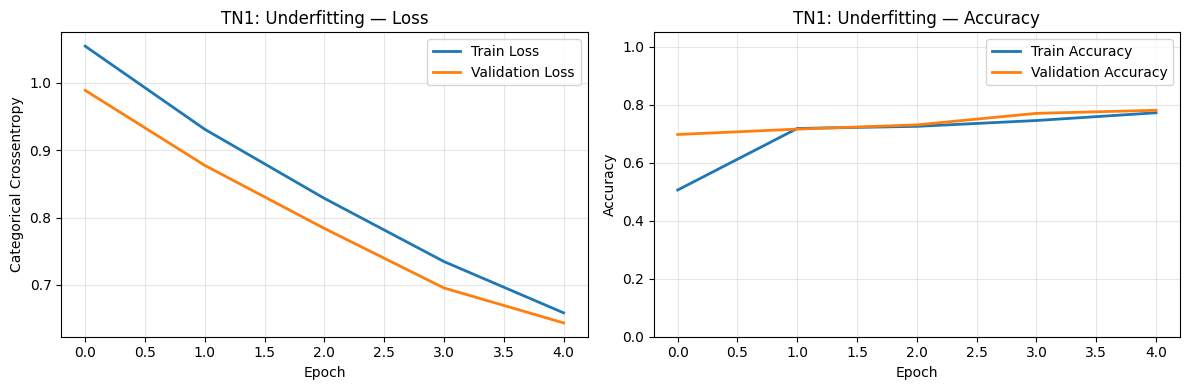


>>> Train Accuracy:      0.7725
>>> Validation Accuracy: 0.7812
>>> Test Accuracy:       0.7626
>>> Nhan xet: Accuracy thap ca Train lan Validation — mo hinh KHONG hoc duoc (Underfitting)


In [32]:
# Co dinh seed de ket qua luon giong nhau o cac lan chay
keras.utils.set_random_seed(42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print('=' * 60)
print('THI NGHIEM 1: UNDERFITTING')
print('Cau hinh: 1 lop an x 4 node, chi train 5 epoch')
print('=' * 60)

model_under = Sequential([
    Input(shape=(36,)),
    Dense(4, activation='relu'),    # chi 4 node — qua it!
    Dense(3, activation='softmax')
])
model_under.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
model_under.summary()

history_under = model_under.fit(
    X_train_cls, y_train_oh,
    validation_data=(X_val_cls, y_val_oh),
    epochs=5,        # chi 5 epoch — qua it!
    batch_size=32,
    verbose=1
)

plot_experiment(history_under, 'TN1: Underfitting')

train_acc_u = history_under.history['accuracy'][-1]
val_acc_u = history_under.history['val_accuracy'][-1]
_, test_acc_u = model_under.evaluate(X_test_cls, y_test_oh, verbose=0)
print(f'\n>>> Train Accuracy:      {train_acc_u:.4f}')
print(f'>>> Validation Accuracy: {val_acc_u:.4f}')
print(f'>>> Test Accuracy:       {test_acc_u:.4f}')
print('>>> Nhan xet: Accuracy thap ca Train lan Validation — mo hinh KHONG hoc duoc (Underfitting)')

### 5.2 Thi nghiem 2: OVERFITTING

**Muc tieu:** Chung minh mo hinh **hoc vet** khi mang qua sau va khong co kiem soat.

**Cau hinh co tinh:**
- **4 lop an** voi 512 → 256 → 128 → 64 node (~190.000 tham so cho ~3.500 mau train)
- Train **200 epoch** — qua nhieu!
- **Khong** dung Dropout hay EarlyStopping

**Ky vong:** Train Accuracy tang cao (>90%) nhung Val Accuracy thap hon ro ret,
Val Loss bat dau tang nguoc — dau hieu dac trung cua Overfitting.

THI NGHIEM 2: OVERFITTING
Cau hinh: 4 lop an (512->256->128->64), train 200 epoch, KHONG Dropout


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 512)            │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,619 (748.51 KB)

 Trainable params: 191,619 (748.51 KB)

 Non-trainable params: 0 (0.00 B)

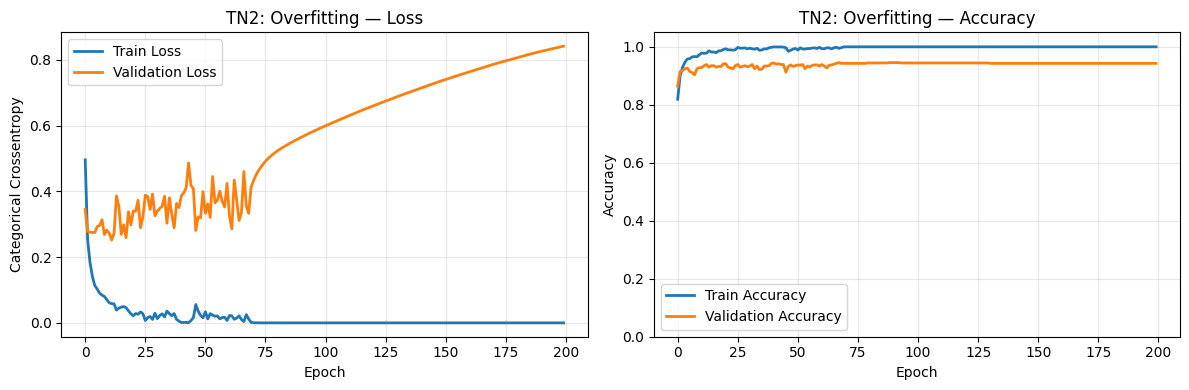


>>> Train Accuracy:      1.0000
>>> Validation Accuracy: 0.9430
>>> Test Accuracy:       0.9337
>>> Chenh lech:          0.0570
>>> Nhan xet: Train Acc cao nhung Validation thap hon ro ret — mo hinh HOC VET (Overfitting)


In [33]:
# Co dinh seed de ket qua luon giong nhau o cac lan chay
keras.utils.set_random_seed(42)

print('=' * 60)
print('THI NGHIEM 2: OVERFITTING')
print('Cau hinh: 4 lop an (512->256->128->64), train 200 epoch, KHONG Dropout')
print('=' * 60)

model_over = Sequential([
    Input(shape=(36,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
model_over.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
model_over.summary()

history_over = model_over.fit(
    X_train_cls, y_train_oh,
    validation_data=(X_val_cls, y_val_oh),
    epochs=200,       # train qua nhieu!
    batch_size=32,
    verbose=0         # tat output de khong spam
)

plot_experiment(history_over, 'TN2: Overfitting')

val_acc_o = history_over.history['val_accuracy'][-1]
_, test_acc_o = model_over.evaluate(X_test_cls, y_test_oh, verbose=0)
train_acc_o = history_over.history['accuracy'][-1]
print(f'\n>>> Train Accuracy:      {train_acc_o:.4f}')
print(f'>>> Validation Accuracy: {val_acc_o:.4f}')
print(f'>>> Test Accuracy:       {test_acc_o:.4f}')
print(f'>>> Chenh lech:          {train_acc_o - val_acc_o:.4f}')
print('>>> Nhan xet: Train Acc cao nhung Validation thap hon ro ret — mo hinh HOC VET (Overfitting)')

### 5.3 Thi nghiem 3: CHUAN HOA (Regularization)

**Muc tieu:** Ap dung cac bien phap khac phuc Overfitting de dat mo hinh toi uu.

**Bien phap su dung:**
- **Dropout(0.3)** sau lop an 1 va **Dropout(0.2)** sau lop an 2 — ngau nhien tat 1 so node
  khi train de mang khong phu thuoc qua vao bat ky node nao.
- **EarlyStopping** (patience=10) — tu dong dung train khi Val Loss khong giam them.
- **Cau hinh vua phai:** 2 lop an (64 → 32), khong qua lon cung khong qua nho.

**Ky vong:** Train va Val Accuracy bam sat nhau, Loss giam deu roi dung — mo hinh tot.

THI NGHIEM 3: CHUAN HOA (Regularization)
Cau hinh: 2 lop an (64->32) + Dropout(0.3, 0.2) + EarlyStopping


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,547 (17.76 KB)

 Trainable params: 4,547 (17.76 KB)

 Non-trainable params: 0 (0.00 B)

EarlyStopping kich hoat tai epoch 83


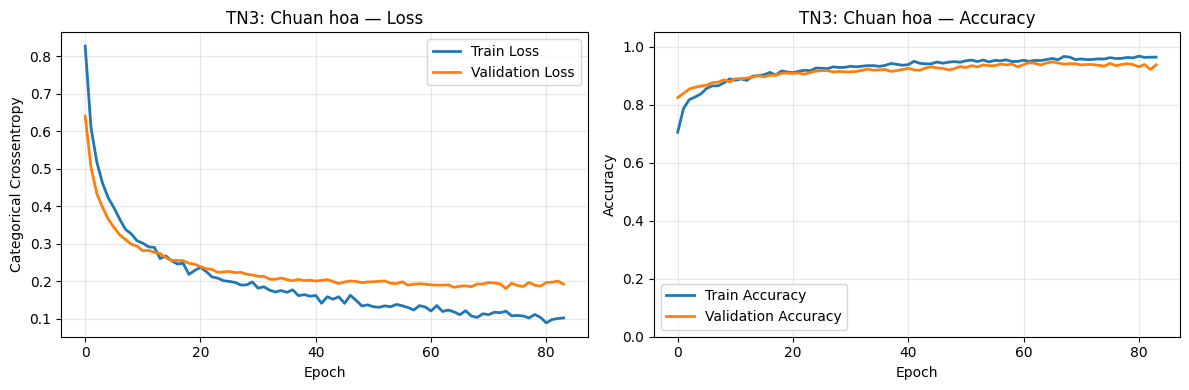


>>> Train Accuracy:      0.9645
>>> Validation Accuracy: 0.9377
>>> Test Accuracy:       0.9271
>>> Chenh lech:          0.0268
>>> Nhan xet: Train va Validation bam sat nhau, Loss giam deu — mo hinh TOT (Chuan hoa)


In [34]:
# Co dinh seed de ket qua luon giong nhau o cac lan chay
keras.utils.set_random_seed(42)


print('=' * 60)
print('THI NGHIEM 3: CHUAN HOA (Regularization)')
print('Cau hinh: 2 lop an (64->32) + Dropout(0.3, 0.2) + EarlyStopping')
print('=' * 60)

model_good = Sequential([
    Input(shape=(36,)),
    Dense(64, activation='relu'),
    Dropout(0.3),                   # tat 30% node ngau nhien
    Dense(32, activation='relu'),
    Dropout(0.2),                   # tat 20% node ngau nhien
    Dense(3, activation='softmax')
])
model_good.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
model_good.summary()

early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_good = model_good.fit(
    X_train_cls, y_train_oh,
    validation_data=(X_val_cls, y_val_oh),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

stopped_epoch = early_stop.stopped_epoch
if stopped_epoch > 0:
    print(f'EarlyStopping kich hoat tai epoch {stopped_epoch}')
else:
    print('Train het 200 epoch (EarlyStopping khong can kich hoat)')

plot_experiment(history_good, 'TN3: Chuan hoa')

val_acc_g = history_good.history['val_accuracy'][-1]
_, test_acc_g = model_good.evaluate(X_test_cls, y_test_oh, verbose=0)
train_acc_g = history_good.history['accuracy'][-1]
print(f'\n>>> Train Accuracy:      {train_acc_g:.4f}')
print(f'>>> Validation Accuracy: {val_acc_g:.4f}')
print(f'>>> Test Accuracy:       {test_acc_g:.4f}')
print(f'>>> Chenh lech:          {abs(train_acc_g - val_acc_g):.4f}')
print('>>> Nhan xet: Train va Validation bam sat nhau, Loss giam deu — mo hinh TOT (Chuan hoa)')

### 5.4 So sanh tong hop 3 Thi nghiem

So sanh **Train Accuracy** vs **Validation Accuracy** cua 3 thi nghiem de thay ro su khac biet
giua Underfitting, Overfitting va mo hinh chuan hoa.

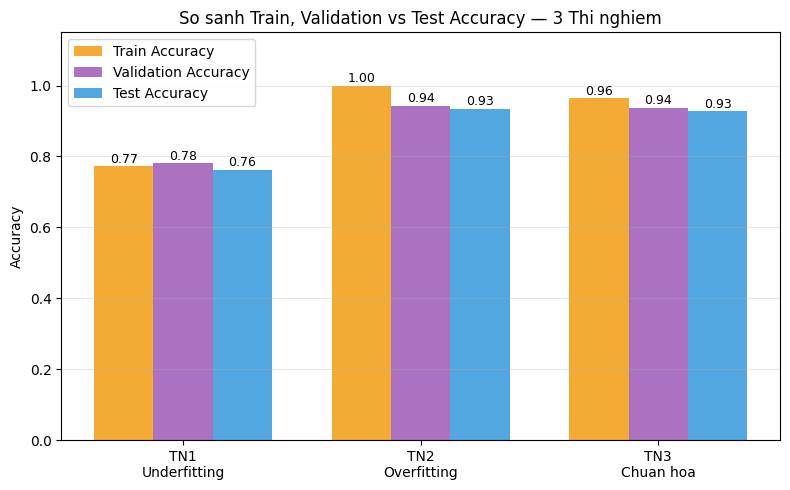


Thi nghiem              Train Acc      Val Acc     Test Acc   Chenh lech
------------------------------------------------------------
Underfitting               0.7725       0.7812       0.7626       0.0086
Overfitting                1.0000       0.9430       0.9337       0.0570
Chuan hoa                  0.9645       0.9377       0.9271       0.0268
------------------------------------------------------------
(!) Overfitting: Train cao, Val thap => chenh lech lon
(!) Underfitting: Ca 2 deu thap => mo hinh khong hoc duoc
(v) Chuan hoa: Train va Val gan nhau => mo hinh tong quat tot


In [35]:
# ========== So sanh Train vs Validation Accuracy — 3 thi nghiem ==========
names = ['TN1\nUnderfitting', 'TN2\nOverfitting', 'TN3\nChuan hoa']

train_accs = [
    history_under.history['accuracy'][-1],
    history_over.history['accuracy'][-1],
    history_good.history['accuracy'][-1],
]
test_accs = [
    test_acc_u,
    test_acc_o,
    test_acc_g,
]
val_accs = [
    history_under.history['val_accuracy'][-1],
    history_over.history['val_accuracy'][-1],
    history_good.history['val_accuracy'][-1],
]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.25
bars1 = ax.bar(x - width, train_accs, width, label='Train Accuracy',
               color='#f39c12', alpha=0.85)
bars2 = ax.bar(x, val_accs, width, label='Validation Accuracy',
               color='#9b59b6', alpha=0.85)
bars3 = ax.bar(x + width, test_accs, width, label='Test Accuracy',
               color='#3498db', alpha=0.85)

ax.set_ylabel('Accuracy')
ax.set_title('So sanh Train, Validation vs Test Accuracy — 3 Thi nghiem')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim([0, 1.15])
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            '{:.2f}'.format(bar.get_height()), ha='center', fontsize=9)

fig.tight_layout()
plt.show()

# Bang tong ket
print()
print('=' * 60)
header = '{:<20} {:>12} {:>12} {:>12} {:>12}'.format('Thi nghiem', 'Train Acc', 'Val Acc', 'Test Acc', 'Chenh lech')
print(header)
print('-' * 60)
for name, tr, va, te in zip(['Underfitting', 'Overfitting', 'Chuan hoa'], train_accs, val_accs, test_accs):
    row = '{:<20} {:>12.4f} {:>12.4f} {:>12.4f} {:>12.4f}'.format(name, tr, va, te, abs(tr - va))
    print(row)
print('-' * 60)
print('(!) Overfitting: Train cao, Val thap => chenh lech lon')
print('(!) Underfitting: Ca 2 deu thap => mo hinh khong hoc duoc')
print('(v) Chuan hoa: Train va Val gan nhau => mo hinh tong quat tot')
print('=' * 60)


### 5.5 ROC/AUC Curve — Mo hinh Chuan hoa (TN3)

**ROC curve** (Receiver Operating Characteristic) the hien kha nang phan biet
giua cac lop cua mo hinh. **AUC** (Area Under Curve) cang gan 1 cang tot.

Vi bai toan co 3 lop, ta ve ROC theo chien luoc **One-vs-Rest** (moi lop duoc
so sanh voi tat ca cac lop con lai).

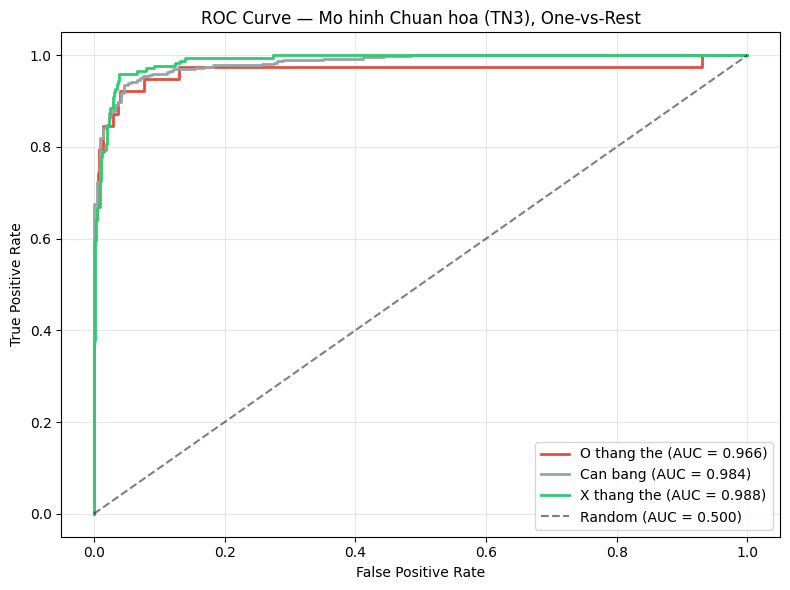

Macro-average AUC: 0.9795

Classification Report:
              precision    recall  f1-score   support

 O thang the       0.85      0.74      0.79        39
    Can bang       0.95      0.96      0.96       540
 X thang the       0.90      0.90      0.90       175

    accuracy                           0.94       754
   macro avg       0.90      0.87      0.88       754
weighted avg       0.94      0.94      0.94       754



In [36]:
# ========== ROC/AUC cho model chuan hoa (TN3) ==========
y_pred_proba = model_good.predict(X_val_cls, verbose=0)

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#e74c3c', '#95a5a6', '#2ecc71']
class_labels = ['O thang the', 'Can bang', 'X thang the']

for i, (color, label) in enumerate(zip(colors_roc, class_labels)):
    fpr, tpr, _ = roc_curve(y_val_oh[:, i], y_pred_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{label} (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Mo hinh Chuan hoa (TN3), One-vs-Rest')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# Macro AUC
macro_auc = roc_auc_score(y_val_oh, y_pred_proba, multi_class='ovr', average='macro')
print(f'Macro-average AUC: {macro_auc:.4f}')

# Classification report
y_pred_cls = np.argmax(y_pred_proba, axis=1)
print()
print('Classification Report:')
print(classification_report(y_val_cls, y_pred_cls,
                            target_names=class_labels))

### 5.6 Cross-Validation

**Cross-validation** chia du lieu thanh K phan (fold), luan phien dung moi phan
lam tap test va cac phan con lai lam tap train. Ket qua trung binh cho biet
mo hinh co **on dinh** va **tong quat hoa tot** hay khong.

O day ta dung **5-Fold Stratified Cross-Validation** tren cau hinh TN3.

5-FOLD CROSS-VALIDATION (cau hinh TN3: 64->32 + Dropout + EarlyStopping)
  Fold 1: Accuracy = 0.9303
  Fold 2: Accuracy = 0.9333
  Fold 3: Accuracy = 0.9323
  Fold 4: Accuracy = 0.9254
  Fold 5: Accuracy = 0.9333

>>> 5-Fold CV Accuracy: 0.9309 +- 0.0030
    Ket qua on dinh (std thap) -> mo hinh tong quat hoa tot.


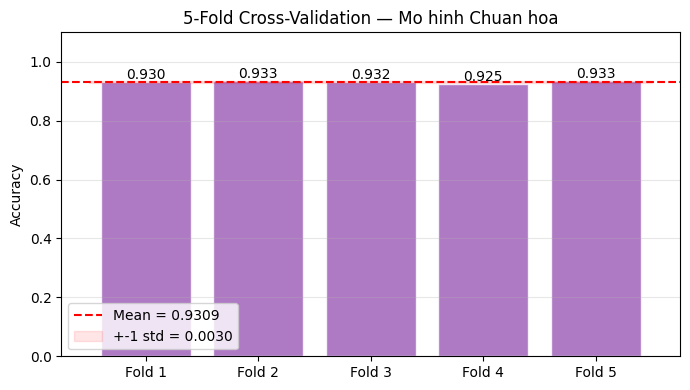

In [37]:
# Co dinh seed de ket qua luon giong nhau o cac lan chay
keras.utils.set_random_seed(42)

# ========== 5-Fold Cross-Validation tren cau hinh TN3 ==========
print('=' * 60)
print('5-FOLD CROSS-VALIDATION (cau hinh TN3: 64->32 + Dropout + EarlyStopping)')
print('=' * 60)

def build_model_good():
    # Tao lai model TN3 moi (trong so ngau nhien) cho moi fold
    m = Sequential([
        Input(shape=(36,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_class)):
    model_cv = build_model_good()
    es = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    model_cv.fit(
        X_all[train_idx], to_categorical(y_class[train_idx], 3),
        epochs=50, batch_size=32, verbose=0, callbacks=[es]
    )
    _, acc = model_cv.evaluate(
        X_all[val_idx], to_categorical(y_class[val_idx], 3), verbose=0
    )
    cv_scores.append(acc)
    print(f'  Fold {fold + 1}: Accuracy = {acc:.4f}')

mean_cv = np.mean(cv_scores)
std_cv = np.std(cv_scores)
print(f'\n>>> 5-Fold CV Accuracy: {mean_cv:.4f} +- {std_cv:.4f}')
print(f'    Ket qua on dinh (std thap) -> mo hinh tong quat hoa tot.')

# Ve bar chart cac fold
fig, ax = plt.subplots(figsize=(7, 4))
fold_names = [f'Fold {i+1}' for i in range(5)]
bars_cv = ax.bar(fold_names, cv_scores, color='#9b59b6', alpha=0.8, edgecolor='white')
ax.axhline(mean_cv, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {mean_cv:.4f}')
ax.fill_between([-0.5, 4.5], mean_cv - std_cv, mean_cv + std_cv,
                color='red', alpha=0.1, label=f'+-1 std = {std_cv:.4f}')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation — Mo hinh Chuan hoa')
ax.set_ylim([0, 1.1])
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, score in zip(bars_cv, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', fontsize=10)

fig.tight_layout()
plt.show()

# Phần 3. Ứng dụng Nâng cao - Minimax + ANN

## 6. Huấn luyện ANN học bắt chước heuristic

Xây và huấn luyện ANN (Keras Sequential) để học bắt chước hàm heuristic, dựa trên dataset vừa sinh ở bước 4.

**Chạy cell dưới sẽ mất khoảng 10-30 giây** và lưu model ra `gomoku_ann_model.keras`.

In [38]:
# Co dinh seed de ket qua luon giong nhau o cac lan chay
keras.utils.set_random_seed(42)

"""
Huấn luyện ANN (Keras Sequential) để học bắt chước hàm heuristic,
dựa trên dữ liệu sinh ra từ data_generation.py.

Xử lý quan trọng: nhãn y có vài trăm mẫu là +-100000 (thế thắng/thua
tuyệt đối) trong khi đa số mẫu chỉ vài chục/trăm điểm. Nếu để nguyên,
MSE sẽ bị các outlier này chi phối hoàn toàn -> ANN học sai lệch.

=> Cách xử lý: GIỚI HẠN (clip) nhãn về khoảng [-CLIP, CLIP] rồi chia
   tỷ lệ tuyến tính về [-1, 1]. Lý do chọn clip tuyến tính thay vì
   log/exp: phép log nén quá mạnh khiến một sai số nhỏ trên thang log
   bị khuếch đại theo cấp số mũ khi giải nén (đã thử và thấy sai lệch
   lớn ngoài thực tế) -> không phù hợp khi minimax chỉ cần ANN ước
   lượng ĐÚNG THỨ TỰ (cái nào tốt hơn cái nào), không cần đúng tuyệt đối.
   Các trạng thái thắng/thua thật ANN không cần đoán chính xác con số
   100000, vì minimax đã tự phát hiện is_terminal() bằng luật cứng rồi.
"""


CLIP_VALUE = 300.0  # các thế cờ thường (chưa kết thúc) hiếm khi vượt mức này


def scale_label(y, clip_value: float = CLIP_VALUE):
    y_clipped = np.clip(y, -clip_value, clip_value)
    return y_clipped / clip_value  # về khoảng [-1, 1]


def inverse_scale_label(y_scaled, clip_value: float = CLIP_VALUE):
    return y_scaled * clip_value


def load_and_prepare_data(path="gomoku_dataset.npz", val_ratio=0.15, test_ratio=0.15, seed=42):
    data = np.load(path)
    X, y = data["X"], data["y"]
    y_scaled = scale_label(y)

    n = X.shape[0]
    rng = np.random.RandomState(seed)
    idx = rng.permutation(n)
    X, y_scaled = X[idx], y_scaled[idx]

    n_test = int(n * test_ratio)
    n_val = int(n * val_ratio)
    n_train = n - n_val - n_test

    X_train, y_train = X[:n_train], y_scaled[:n_train]
    X_val, y_val = X[n_train:n_train + n_val], y_scaled[n_train:n_train + n_val]
    X_test, y_test = X[n_train + n_val:], y_scaled[n_train + n_val:]

    print(f"Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)} "
          f"({len(X_train)/n:.0%}/{len(X_val)/n:.0%}/{len(X_test)/n:.0%})")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def build_model(hidden_layers=(64, 32), input_dim=36):
    """ANN dạng Sequential: Lego-style model.add(Dense(...)) như đề bài gợi ý."""
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))
    model.add(layers.Dense(1, activation="tanh"))  # nhãn đã scale về [-1, 1]
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


def plot_history(history, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="Train MAE")
    axes[1].plot(history.history["val_mae"], label="Validation MAE")
    axes[1].set_title(f"{title} - MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(filename, dpi=120)
    plt.close(fig)
    print(f"  Đã lưu đồ thị: {filename}")


if __name__ == "__main__":
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_and_prepare_data()

    print("\n=== Huấn luyện ANN heuristic cho Gomoku ===")
    model = build_model(hidden_layers=(64, 32))
    model.summary()

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    plot_history(history, "Gomoku Heuristic ANN", "gomoku_ann_training.png")

    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest MSE (thang log): {test_loss:.4f} | Test MAE (thang log): {test_mae:.4f}")

    # Kiểm tra trực quan trên thang điểm THẬT (sau khi giải nén)
    y_pred_scaled = model.predict(X_test[:5], verbose=0).flatten()
    y_pred_real = inverse_scale_label(y_pred_scaled)
    y_true_real = inverse_scale_label(y_test[:5])
    print("\nSo sánh 5 mẫu test (thang điểm thật):")
    for true_v, pred_v in zip(y_true_real, y_pred_real):
        print(f"  Thật: {true_v:8.1f}   |   ANN dự đoán: {pred_v:8.1f}")

    model.save("gomoku_ann_model.keras")
    print("\nĐã lưu model: gomoku_ann_model.keras")


Train/Val/Test split: 3519/753/753 (70%/15%/15%)

=== Huấn luyện ANN heuristic cho Gomoku ===


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

  Đã lưu đồ thị: gomoku_ann_training.png

Test MSE (thang log): 0.0328 | Test MAE (thang log): 0.0981

So sánh 5 mẫu test (thang điểm thật):
  Thật:     23.0   |   ANN dự đoán:     17.8
  Thật:     11.0   |   ANN dự đoán:     15.4
  Thật:      0.0   |   ANN dự đoán:     -0.0
  Thật:     29.0   |   ANN dự đoán:    -10.6
  Thật:     30.0   |   ANN dự đoán:     98.2

Đã lưu model: gomoku_ann_model.keras


## 7. Dùng ANN thay heuristic trong Minimax

Bọc ANN đã huấn luyện thành `eval_fn`, gọi thẳng `model.predict()` của Keras cho từng
bàn cờ (đơn giản, dễ hiểu, đúng với boilerplate của đề). Vì không viết forward-pass
bằng numpy nữa nên tốc độ sẽ chậm hơn — bù lại nên chọn `depth` nhỏ (1-2) ở các phần sau.


In [39]:
"""
Đây là phần "lõi" của Phần 3 đề bài: thay hàm heuristic tay bằng ANN
đã huấn luyện, theo đúng boilerplate trong đề:

    def get_heuristic_value(board_state):
        input_vector = preprocess(board_state)
        score = model.predict(input_vector)
        return score

Ở đây gọi THẲNG `model.predict()` của Keras cho từng bàn cờ một — không tự viết
forward-pass bằng numpy nữa, để source đơn giản và bám sát boilerplate của đề.

Đánh đổi: `model.predict()` có overhead khởi tạo khá lớn cho mỗi lần gọi, và vì
Minimax (Phần 3) không dùng Alpha-Beta nên số lần gọi eval_fn khá nhiều. Vì vậy khi
dùng ANNHeuristic làm eval_fn cho minimax, nên chọn `depth` nhỏ (1-2) và số trận
đánh giá vừa phải, để chương trình chạy trong thời gian hợp lý.
"""

class ANNHeuristic:
    """Bọc model Keras thành 1 eval_fn(board) -> float, dùng được trực tiếp
    trong minimax_ai.minimax(..., eval_fn=...) giống như evaluate_heuristic."""

    def __init__(self, model_path: str = "gomoku_ann_model.keras"):
        self.model = keras.models.load_model(model_path)

    def get_heuristic_value(self, board: GomokuBoard) -> float:
        # 1. Chuyển bàn cờ về vector (input của mạng) -- giống preprocess() trong đề
        input_vector = board.to_vector().reshape(1, -1)
        # 2. ANN dự đoán điểm số thế trận (model.predict trực tiếp, trên thang đã nén)
        score_scaled = float(self.model.predict(input_vector, verbose=0)[0][0])
        # 3. Giải nén về thang điểm thật để so sánh công bằng với heuristic tay
        return float(inverse_scale_label(np.array([score_scaled]))[0])

    def __call__(self, board: GomokuBoard) -> float:
        return self.get_heuristic_value(board)


if __name__ == "__main__":
    import time

    ann_eval = ANNHeuristic()

    b = GomokuBoard()
    for (r, c) in [(2, 2), (2, 3), (2, 4)]:
        b.grid[r, c] = 1  # X có 3 quân sống

    print("Heuristic tay :", evaluate_heuristic(b))
    print("ANN dự đoán   :", ann_eval(b))

    # Đo tốc độ gọi model.predict() trực tiếp (chậm hơn forward-pass numpy,
    # nhưng đơn giản và dễ hiểu hơn nhiều).
    t0 = time.time()
    for _ in range(20):
        ann_eval(b)
    t1 = time.time()
    print(f"\n20 lần gọi ANN heuristic (model.predict trực tiếp): {t1 - t0:.3f}s "
          f"({(t1 - t0) / 20:.4f}s / lần)")


Heuristic tay : 110.0
ANN dự đoán   : 180.62354922294617

20 lần gọi ANN heuristic (model.predict trực tiếp): 1.307s (0.0654s / lần)


## 8. `evaluate_models` — Đánh giá ANN-Minimax vs Random

Tiêu chí rubric: ANN-Minimax phải **thông minh hơn Random rõ rệt**. Chỉ so 1 cặp
đấu duy nhất (ANN-Minimax vs Random) để giữ source đơn giản.

**Chạy cell dưới sẽ mất một lúc** (mỗi nước đi của ANN-Minimax phải gọi
`model.predict()` nhiều lần vì không có Alpha-Beta) — có thể chỉnh
`n_games_per_side` và `depth_ann` nhỏ lại nếu chạy quá lâu.


In [40]:
"""
Đánh giá xem ANN-Minimax có "chơi thông minh hơn ngẫu nhiên" hay không
-- đây chính là tiêu chí rubric của đề bài cho Phần 3 (không cần thắng
tuyệt đối Minimax-tay, chỉ cần hơn random rõ rệt là đạt mục tiêu).

  ANN-Minimax  vs  Random

Đấu N trận, đổi vai trò X/O luân phiên để công bằng (loại bỏ lợi thế đi trước cố định).
"""

def random_move(board: GomokuBoard):
    moves = board.candidate_moves(radius=1)
    return random.choice(moves) if moves else None


def play_match(agent_x, agent_o, max_moves: int = 36):
    """
    agent_x, agent_o: hàm (board) -> (row, col) trả về nước đi cho từng bên.
    Trả về: 1 nếu X thắng, -1 nếu O thắng, 0 nếu hòa.
    """
    board = GomokuBoard()
    while not board.is_terminal() and len(board.move_history) < max_moves:
        agent = agent_x if board.current_player == 1 else agent_o
        move = agent(board)
        if move is None:
            break
        board.make_move(*move)
    return board.winner if board.winner is not None else 0


def make_minimax_agent(eval_fn, depth: int):
    return lambda board: get_best_move(board, depth=depth, eval_fn=eval_fn)


def run_evaluation(n_games_per_side: int, ann_eval, depth_ann: int = 1):
    """
    ANN-Minimax chơi `n_games_per_side` trận đi X và `n_games_per_side` trận
    đi O trước Random -> tổng 2*n_games_per_side trận.
    """
    random.seed(123)

    ann_agent = make_minimax_agent(ann_eval, depth_ann)

    ann_wins, random_wins, draws = 0, 0, 0

    for _ in range(n_games_per_side):
        result = play_match(ann_agent, random_move)  # ANN = X, Random = O
        if result == 1:
            ann_wins += 1
        elif result == -1:
            random_wins += 1
        else:
            draws += 1

    for _ in range(n_games_per_side):
        result = play_match(random_move, ann_agent)  # Random = X, ANN = O
        if result == 1:
            random_wins += 1
        elif result == -1:
            ann_wins += 1
        else:
            draws += 1

    total = 2 * n_games_per_side
    print("=" * 60)
    print(f"ANN-Minimax vs Random  ({total} trận, đổi vai X/O luân phiên)")
    print(f"  ANN-Minimax thắng: {ann_wins} ({ann_wins/total:.0%})")
    print(f"  Random thắng     : {random_wins} ({random_wins/total:.0%})")
    print(f"  Hòa              : {draws} ({draws/total:.0%})")


if __name__ == "__main__":
    import time
    ann_eval = ANNHeuristic()
    t0 = time.time()
    run_evaluation(n_games_per_side=20, ann_eval=ann_eval, depth_ann=1)
    print(f"\nTổng thời gian đánh giá: {time.time() - t0:.1f}s")


ANN-Minimax vs Random  (40 trận, đổi vai X/O luân phiên)
  ANN-Minimax thắng: 29 (72%)
  Random thắng     : 11 (28%)
  Hòa              : 0 (0%)

Tổng thời gian đánh giá: 405.0s


## 9. `play_game` — Choi thu voi ANN-Minimax (tkinter)

Giao dien do hoa don gian dung **tkinter** (thu vien co san trong Python).

- **Ban** di quan **X** (den) — click vao o trong.
- **AI** (ANN-Minimax) di quan **O** (do) — tu dong dap tra.
- Thang khi co **4 quan lien tiep** (ngang / doc / cheo).

> **Luu y:** Cell nay mo cua so tkinter rieng. Dong cua so de quay lai notebook.
> Neu chay tren Google Colab thi tkinter **khong hoat dong** — chi chay duoc o may local.

In [41]:
import tkinter as tk
from tkinter import messagebox

# ========== Cau hinh ==========
CELL_PX    = 80          # kich thuoc moi o (pixel)
AI_DEPTH   = 1           # do sau Minimax (1-2 de chay nhanh)
HUMAN      = 1           # X di truoc
AI         = -1          # O di sau

# ========== Tao eval_fn ==========
# Dung ANN-Minimax neu model da duoc load, nguoc lai dung heuristic tay
try:
    ai_eval = ANNHeuristic()
    AI_NAME = 'ANN-Minimax'
    print('Da load ANN model -> AI se dung ANN-Minimax')
except Exception:
    ai_eval = evaluate_heuristic
    AI_NAME = 'Minimax (heuristic tay)'
    print('Khong tim thay model ANN -> AI se dung heuristic tay')

class GomokuGUI:
    def __init__(self):
        self.board = GomokuBoard()
        self.game_over = False

        # --- Cua so chinh ---
        self.root = tk.Tk()
        self.root.title('Gomoku 6x6 — Ban (X) vs ' + AI_NAME + ' (O)')
        self.root.resizable(False, False)

        # --- Canvas ve ban co ---
        canvas_size = BOARD_SIZE * CELL_PX
        self.canvas = tk.Canvas(
            self.root, width=canvas_size, height=canvas_size,
            bg='#DEB887', highlightthickness=0
        )
        self.canvas.pack(padx=12, pady=(12, 4))

        # --- Thanh trang thai ---
        self.status = tk.Label(
            self.root, text='Luot cua ban (X) — Click de dat quan',
            font=('Arial', 13), fg='#2c3e50'
        )
        self.status.pack(pady=4)

        # --- Nut choi lai ---
        btn_frame = tk.Frame(self.root)
        btn_frame.pack(pady=(0, 10))
        tk.Button(
            btn_frame, text='Choi lai', command=self.reset,
            font=('Arial', 11), padx=16, pady=4
        ).pack()

        # --- Bat su kien click ---
        self.canvas.bind('<Button-1>', self.on_click)
        self.draw_board()

        self.root.mainloop()

    # ----- Ve ban co -----
    def draw_board(self):
        self.canvas.delete('all')
        sz = BOARD_SIZE

        # Ve luoi
        for i in range(sz + 1):
            self.canvas.create_line(
                0, i * CELL_PX, sz * CELL_PX, i * CELL_PX, fill='#8B7355'
            )
            self.canvas.create_line(
                i * CELL_PX, 0, i * CELL_PX, sz * CELL_PX, fill='#8B7355'
            )

        # Ve quan co
        for r in range(sz):
            for c in range(sz):
                v = self.board.grid[r][c]
                if v != 0:
                    self.draw_piece(r, c, v)

    def draw_piece(self, row, col, player):
        cx = col * CELL_PX + CELL_PX // 2
        cy = row * CELL_PX + CELL_PX // 2
        radius = CELL_PX // 2 - 6

        if player == 1:   # X — den
            color, outline, txt = '#2c3e50', '#1a252f', 'X'
        else:             # O — do
            color, outline, txt = '#e74c3c', '#c0392b', 'O'

        self.canvas.create_oval(
            cx - radius, cy - radius, cx + radius, cy + radius,
            fill=color, outline=outline, width=2
        )
        self.canvas.create_text(
            cx, cy, text=txt, fill='white', font=('Arial', 22, 'bold')
        )

    # ----- Xu ly click -----
    def on_click(self, event):
        if self.game_over:
            return

        col = event.x // CELL_PX
        row = event.y // CELL_PX
        if not (0 <= row < BOARD_SIZE and 0 <= col < BOARD_SIZE):
            return
        if self.board.grid[row][col] != 0:
            return

        # --- Nguoi choi di ---
        self.board.make_move(row, col)
        self.draw_board()

        if self.check_end():
            return

        # --- AI suy nghi ---
        self.status.config(text=AI_NAME + ' dang suy nghi...')
        self.root.update()

        move = get_best_move(self.board, depth=AI_DEPTH, eval_fn=ai_eval)
        if move:
            self.board.make_move(*move)
            self.draw_board()

        if self.check_end():
            return

        self.status.config(text='Luot cua ban (X) — Click de dat quan')

    # ----- Kiem tra ket thuc -----
    def check_end(self):
        w = self.board.winner
        if w == HUMAN:
            self.game_over = True
            self.status.config(text='Ban thang! (X)', fg='#27ae60')
            messagebox.showinfo('Ket qua', 'Chuc mung — Ban thang!')
            return True
        elif w == AI:
            self.game_over = True
            self.status.config(text=AI_NAME + ' thang! (O)', fg='#e74c3c')
            messagebox.showinfo('Ket qua', AI_NAME + ' thang!')
            return True
        elif w == 0 or self.board.is_full():
            self.game_over = True
            self.status.config(text='Hoa!', fg='#f39c12')
            messagebox.showinfo('Ket qua', 'Hoa!')
            return True
        return False

    # ----- Reset -----
    def reset(self):
        self.board = GomokuBoard()
        self.game_over = False
        self.status.config(text='Luot cua ban (X) — Click de dat quan', fg='#2c3e50')
        self.draw_board()

# ========== Chay game ==========
GomokuGUI()


Da load ANN model -> AI se dung ANN-Minimax
